In [4]:
# ============================================================
# DAY 5 — FINAL PRODUCTION ML PROJECT
# UCI ADULT CENSUS INCOME
# ============================================================

from pathlib import Path
import json
import platform
import warnings
import sys
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import scipy
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ARTIFACT_PATH = Path("day4_final_pipeline.joblib")
OUTPUT_DIR = Path("day5_final")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/adult-all.csv"
)

COLUMN_NAMES = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

print("=" * 70)
print("DAY 5 — FINAL PRODUCTION ML PROJECT")
print("=" * 70)

print("\nEnvironment")
print("-" * 70)
print("Python       :", platform.python_version())
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("SciPy        :", scipy.__version__)
print("Scikit-learn :", sklearn.__version__)
print("XGBoost      :", xgb.__version__)

print("\nArtifact:", ARTIFACT_PATH)
print("Output  :", OUTPUT_DIR)

DAY 5 — FINAL PRODUCTION ML PROJECT

Environment
----------------------------------------------------------------------
Python       : 3.13.9
NumPy        : 2.3.5
Pandas       : 2.3.3
SciPy        : 1.16.3
Scikit-learn : 1.7.2
XGBoost      : 3.4.1

Artifact: day4_final_pipeline.joblib
Output  : day5_final


In [5]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_URL,
    header=None,
    names=COLUMN_NAMES,
    skipinitialspace=True
)

# Same missing-value handling as Day 4
df = df.replace("?", np.nan)

# Same target mapping
df["class_numeric"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Validate target
if df["class_numeric"].isna().any():
    raise ValueError("Unexpected target values found.")

numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

X = df.drop(columns=["income", "class_numeric"])
y = df["class_numeric"]

# ------------------------------------------------------------
# EXACT DAY 4 SPLIT
# ------------------------------------------------------------

X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev,
    y_train_dev,
    test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=y_train_dev
)

print("Dataset shape:", df.shape)

print("\nSplit sizes")
print("-" * 50)

for name, data in [
    ("Train", X_train),
    ("Dev", X_dev),
    ("Test", X_test)
]:
    print(
        f"{name:<10}: "
        f"{len(data):>6} rows "
        f"({len(data) / len(df) * 100:.2f}%)"
    )

print("\nTarget distribution")

for name, target in [
    ("Train", y_train),
    ("Dev", y_dev),
    ("Test", y_test)
]:
    print(
        f"{name:<10}: "
        f"positive rate = {target.mean() * 100:.2f}%"
    )

Dataset shape: (48842, 16)

Split sizes
--------------------------------------------------
Train     :  34188 rows (70.00%)
Dev       :   4885 rows (10.00%)
Test      :   9769 rows (20.00%)

Target distribution
Train     : positive rate = 23.93%
Dev       : positive rate = 23.93%
Test      : positive rate = 23.93%


In [6]:
# ============================================================
# DAY 4 FEATURE ENGINEERING
# MUST EXIST BEFORE joblib.load()
# ============================================================

def engineer_features(X):
    """
    Reproduce the exact feature engineering used in Day 4.

    Input:
        Raw Adult Census DataFrame

    Output:
        Raw + engineered feature DataFrame
    """

    X = X.copy()

    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=[
            "<25",
            "25-34",
            "35-44",
            "45-54",
            "55-64",
            "65+"
        ],
        right=False
    ).astype(object)

    X["hours_bin"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 35, 45, 200],
        labels=[
            "part-time(<35)",
            "full-time(35-45)",
            "overtime(>45)"
        ],
        right=False
    ).astype(object)

    X["capital_gain_flag"] = (
        X["capital-gain"] > 0
    ).astype(int)

    X["log_capital_gain"] = np.log1p(
        X["capital-gain"]
    )

    X["capital_loss_flag"] = (
        X["capital-loss"] > 0
    ).astype(int)

    X["log_capital_loss"] = np.log1p(
        X["capital-loss"]
    )

    X["higher_ed"] = (
        X["education-num"] >= 13
    ).astype(int)

    X["edu_hours_interaction"] = (
        X["education-num"] *
        X["hours-per-week"]
    )

    return X


new_num_cont = [
    "log_capital_gain",
    "log_capital_loss",
    "edu_hours_interaction"
]

new_num_flag = [
    "capital_gain_flag",
    "capital_loss_flag",
    "higher_ed"
]

new_cat = [
    "age_bucket",
    "hours_bin"
]


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])


flag_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "num_eng",
        numeric_pipeline,
        new_num_cont
    ),
    (
        "flag_eng",
        flag_pipeline,
        new_num_flag
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    ),
    (
        "cat_eng",
        categorical_pipeline,
        new_cat
    )
])

print("Feature engineering function ready.")
print("Preprocessor definition ready.")

Feature engineering function ready.
Preprocessor definition ready.


In [8]:
# ============================================================
# LOAD SAVED DAY 4 PIPELINE
# ============================================================

if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {ARTIFACT_PATH.resolve()}"
    )

final_pipeline = joblib.load(ARTIFACT_PATH)

print("Artifact loaded successfully.")
print("\nPipeline:")
print(final_pipeline)

Artifact loaded successfully.

Pipeline:
Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x00000238D8E76340>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                               

In [9]:
# ============================================================
# PIPELINE SANITY CHECK
# ============================================================

print("=" * 70)
print("PIPELINE SANITY CHECK")
print("=" * 70)

# Verify expected pipeline structure
if not hasattr(final_pipeline, "predict_proba"):
    raise TypeError(
        "Loaded artifact does not provide predict_proba()."
    )

if not hasattr(final_pipeline, "predict"):
    raise TypeError(
        "Loaded artifact does not provide predict()."
    )

# Test on a tiny unseen sample
sample = X_test.iloc[:5].copy()

sample_probabilities = final_pipeline.predict_proba(sample)

print("\nProbability shape:", sample_probabilities.shape)

print("\nProbabilities:")
print(sample_probabilities)

print("\nPipeline accepts raw input successfully.")

assert sample_probabilities.shape == (5, 2)

print("\n✓ Pipeline sanity check PASSED")

PIPELINE SANITY CHECK

Probability shape: (5, 2)

Probabilities:
[[0.99555856 0.00444145]
 [0.92742145 0.07257853]
 [0.9974585  0.00254147]
 [0.96625996 0.03374004]
 [0.44499296 0.55500704]]

Pipeline accepts raw input successfully.

✓ Pipeline sanity check PASSED


In [10]:
# ============================================================
# DATA LEAKAGE / OVERLAP CHECK
# ============================================================

def dataframe_fingerprint(data):
    """
    Create row fingerprints for detecting exact duplicate rows
    across splits.
    """
    return pd.util.hash_pandas_object(
        data.astype(str),
        index=False
    )


train_hashes = set(dataframe_fingerprint(X_train))
dev_hashes = set(dataframe_fingerprint(X_dev))
test_hashes = set(dataframe_fingerprint(X_test))

train_dev_overlap = len(train_hashes.intersection(dev_hashes))
train_test_overlap = len(train_hashes.intersection(test_hashes))
dev_test_overlap = len(dev_hashes.intersection(test_hashes))

print("=" * 70)
print("DATA LEAKAGE / OVERLAP CHECK")
print("=" * 70)

print("Train ∩ Dev :", train_dev_overlap)
print("Train ∩ Test:", train_test_overlap)
print("Dev ∩ Test  :", dev_test_overlap)

if any([
    train_dev_overlap,
    train_test_overlap,
    dev_test_overlap
]):
    print("\nWARNING: exact duplicate rows exist across splits.")
else:
    print("\n✓ No exact row overlap detected.")

print(
    "\nImportant:",
    "preprocessing is contained inside the pipeline,",
    "so imputers/scalers/encoders are fitted during training"
    " rather than manually fitted on test data."
)

DATA LEAKAGE / OVERLAP CHECK
Train ∩ Dev : 10
Train ∩ Test: 15
Dev ∩ Test  : 2


Important: preprocessing is contained inside the pipeline, so imputers/scalers/encoders are fitted during training rather than manually fitted on test data.


In [11]:
# ============================================================
# THRESHOLD SELECTION — DEV ONLY
# ============================================================

dev_probabilities = final_pipeline.predict_proba(
    X_dev
)[:, 1]

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_rows = []

for threshold in thresholds:

    dev_predictions = (
        dev_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_dev,
            dev_predictions
        ),
        "precision": precision_score(
            y_dev,
            dev_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_dev,
            dev_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_dev,
            dev_predictions,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

FINAL_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("=" * 70)
print("THRESHOLD SELECTION")
print("=" * 70)

print(
    f"Selected threshold: {FINAL_THRESHOLD:.2f}"
)

print(
    f"Dev F1       : {best_threshold_row['f1']:.4f}"
)

print(
    f"Dev Precision : {best_threshold_row['precision']:.4f}"
)

print(
    f"Dev Recall    : {best_threshold_row['recall']:.4f}"
)

print(
    f"Dev Accuracy  : {best_threshold_row['accuracy']:.4f}"
)

THRESHOLD SELECTION
Selected threshold: 0.35
Dev F1       : 0.7312
Dev Precision : 0.6705
Dev Recall    : 0.8041
Dev Accuracy  : 0.8585


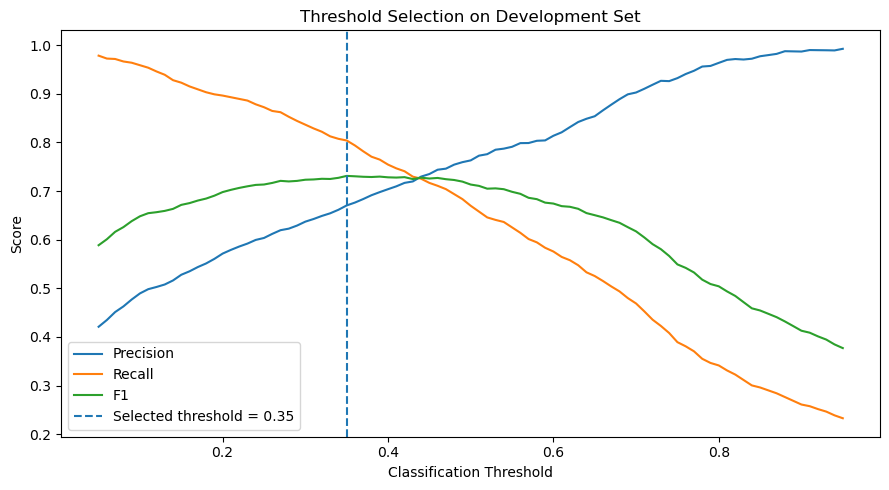

In [12]:
# ============================================================
# THRESHOLD ANALYSIS PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection on Development Set")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "threshold_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

print("=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)

# Predict probabilities
test_probabilities = final_pipeline.predict_proba(
    X_test
)[:, 1]

# Apply threshold selected ONLY using dev set
test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

final_metrics = {
    "accuracy": accuracy_score(
        y_test,
        test_predictions
    ),

    "precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "f1": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_test,
        test_probabilities
    ),

    "pr_auc": average_precision_score(
        y_test,
        test_probabilities
    ),

    "brier_score": brier_score_loss(
        y_test,
        test_probabilities
    ),

    "threshold": FINAL_THRESHOLD
}

final_metrics_df = pd.DataFrame([
    final_metrics
])

print(
    final_metrics_df.round(4).to_string(
        index=False
    )
)

print("\nClassification Report")
print("-" * 70)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "<=50K",
            ">50K"
        ],
        digits=4,
        zero_division=0
    )
)

# Save
final_metrics_df.to_csv(
    OUTPUT_DIR / "final_metrics.csv",
    index=False
)

FINAL TEST EVALUATION
 accuracy  precision  recall     f1  roc_auc  pr_auc  brier_score  threshold
   0.8623     0.6856  0.7844 0.7317   0.9311  0.8357       0.0863       0.35

Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K     0.9290    0.8868    0.9074      7431
        >50K     0.6856    0.7844    0.7317      2338

    accuracy                         0.8623      9769
   macro avg     0.8073    0.8356    0.8195      9769
weighted avg     0.8707    0.8623    0.8654      9769



CONFUSION MATRIX
True Negatives : 6590
False Positives: 841
False Negatives: 504
True Positives : 1834


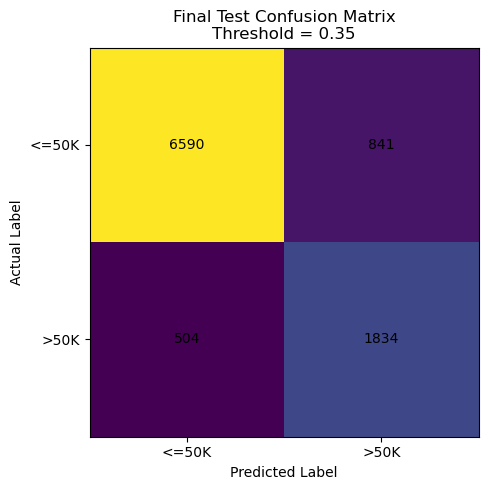

In [14]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_predictions
)

tn, fp, fn, tp = cm.ravel()

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    f"Final Test Confusion Matrix\n"
    f"Threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["<=50K", ">50K"]
)

plt.yticks(
    [0, 1],
    ["<=50K", ">50K"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

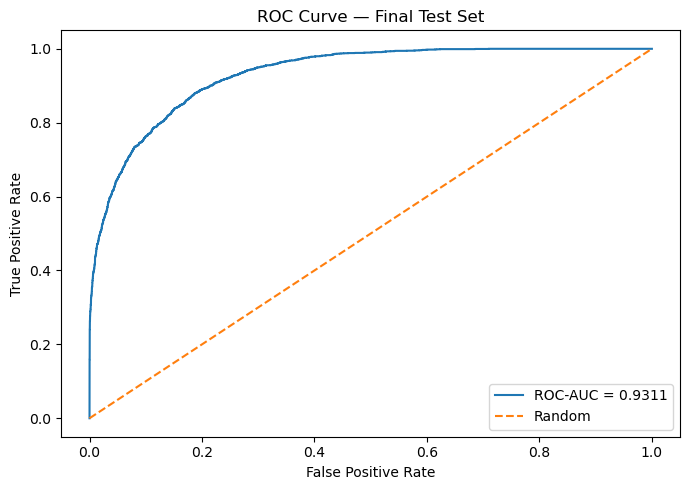

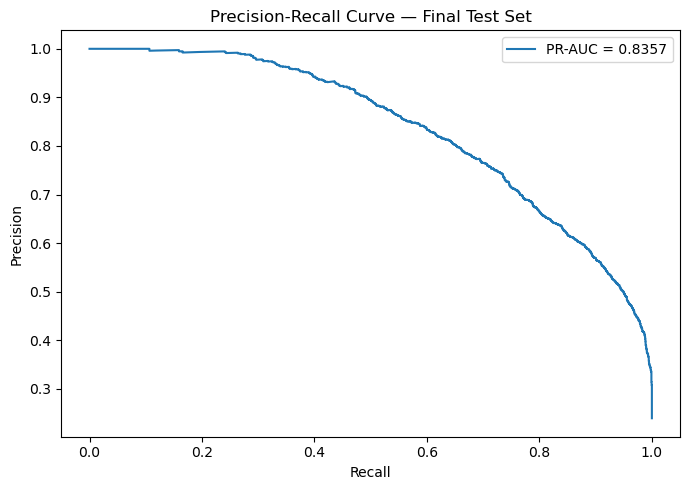

In [15]:
# ============================================================
# ROC + PRECISION-RECALL CURVES
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

# ROC
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_metrics['roc_auc']:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Test Set")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Precision Recall
plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {final_metrics['pr_auc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Test Set")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "precision_recall_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

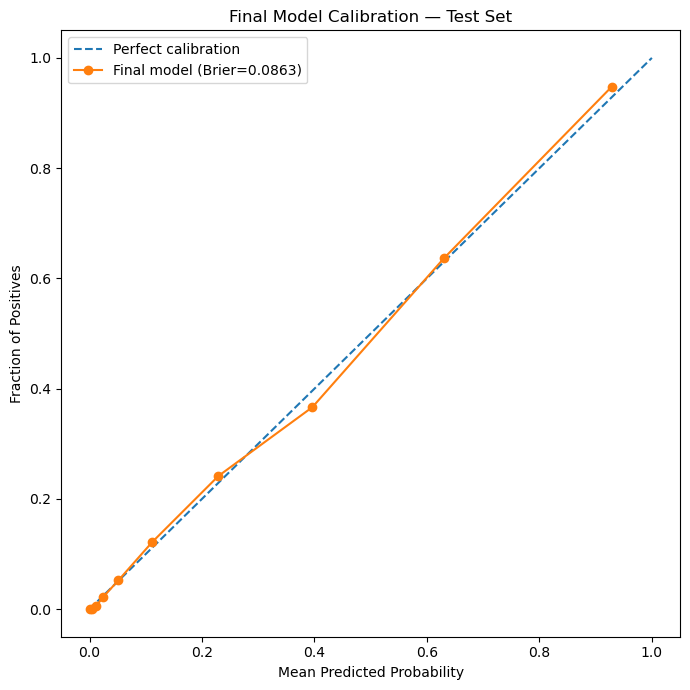

Brier score: 0.0863


In [16]:
# ============================================================
# CALIBRATION CURVE
# ============================================================

fraction_positive, mean_predicted = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    mean_predicted,
    fraction_positive,
    "o-",
    label=(
        f"Final model "
        f"(Brier={final_metrics['brier_score']:.4f})"
    )
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Final Model Calibration — Test Set")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Brier score: "
    f"{final_metrics['brier_score']:.4f}"
)

In [17]:
# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

test_predictions_df = X_test.copy()

test_predictions_df["actual"] = y_test.values

test_predictions_df["probability"] = (
    test_probabilities
)

test_predictions_df["prediction"] = (
    test_predictions
)

test_predictions_df["error_type"] = np.select(
    [
        (
            (test_predictions_df["actual"] == 0) &
            (test_predictions_df["prediction"] == 1)
        ),
        (
            (test_predictions_df["actual"] == 1) &
            (test_predictions_df["prediction"] == 0)
        ),
        (
            test_predictions_df["actual"] ==
            test_predictions_df["prediction"]
        )
    ],
    [
        "False Positive",
        "False Negative",
        "Correct"
    ],
    default="Unknown"
)

test_predictions_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "test_predictions.csv"
)

Saved: day5_final\test_predictions.csv


In [18]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

errors_df = test_predictions_df[
    test_predictions_df["error_type"].isin([
        "False Positive",
        "False Negative"
    ])
].copy()

print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print("\nTotal errors:", len(errors_df))

print(
    "\nError breakdown:"
)

print(
    errors_df["error_type"].value_counts()
)

print(
    "\nFalse Positive rate:",
    f"{fp / len(y_test):.4%}"
)

print(
    "False Negative rate:",
    f"{fn / len(y_test):.4%}"
)

errors_df.to_csv(
    OUTPUT_DIR / "error_analysis.csv",
    index=False
)

print(
    "\nSaved:",
    OUTPUT_DIR / "error_analysis.csv"
)

ERROR ANALYSIS

Total errors: 1345

Error breakdown:
error_type
False Positive    841
False Negative    504
Name: count, dtype: int64

False Positive rate: 8.6089%
False Negative rate: 5.1592%

Saved: day5_final\error_analysis.csv


In [19]:
# ============================================================
# ERROR PATTERN ANALYSIS
# ============================================================

def error_summary_by_column(
    data,
    error_mask,
    columns
):
    rows = []

    error_data = data.loc[error_mask]

    for column in columns:

        if column not in error_data.columns:
            continue

        counts = (
            error_data[column]
            .value_counts(dropna=False)
            .head(10)
        )

        for value, count in counts.items():

            rows.append({
                "feature": column,
                "value": value,
                "error_count": count
            })

    return pd.DataFrame(rows)


fp_mask = (
    (test_predictions_df["actual"] == 0) &
    (test_predictions_df["prediction"] == 1)
)

fn_mask = (
    (test_predictions_df["actual"] == 1) &
    (test_predictions_df["prediction"] == 0)
)

important_categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

print("=" * 70)
print("FALSE POSITIVE PATTERNS")
print("=" * 70)

fp_patterns = error_summary_by_column(
    test_predictions_df,
    fp_mask,
    important_categorical_features
)

print(fp_patterns.to_string(index=False))


print("\n")
print("=" * 70)
print("FALSE NEGATIVE PATTERNS")
print("=" * 70)

fn_patterns = error_summary_by_column(
    test_predictions_df,
    fn_mask,
    important_categorical_features
)

print(fn_patterns.to_string(index=False))

FALSE POSITIVE PATTERNS
       feature              value  error_count
     workclass            Private          548
     workclass          Local-gov           69
     workclass   Self-emp-not-inc           66
     workclass       Self-emp-inc           45
     workclass                NaN           42
     workclass        Federal-gov           37
     workclass          State-gov           34
     education            HS-grad          235
     education       Some-college          206
     education          Bachelors          198
     education            Masters           62
     education          Assoc-voc           48
     education         Assoc-acdm           33
     education        Prof-school           29
     education          Doctorate           27
     education               11th            2
     education               10th            1
marital-status Married-civ-spouse          786
marital-status           Divorced           27
marital-status      Never-married   

In [20]:
# ============================================================
# SUBGROUP PERFORMANCE
# ============================================================

def subgroup_metrics(
    data,
    actual,
    predicted,
    probability,
    feature
):
    rows = []

    for group in data[feature].dropna().unique():

        mask = (
            data[feature] == group
        )

        y_true_group = actual.loc[mask]
        y_pred_group = predicted[mask]
        prob_group = probability[mask]

        if len(y_true_group) < 30:
            continue

        rows.append({
            "feature": feature,
            "group": group,
            "n": len(y_true_group),
            "positive_rate": y_true_group.mean(),
            "accuracy": accuracy_score(
                y_true_group,
                y_pred_group
            ),
            "precision": precision_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            ),
            "recall": recall_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            ),
            "f1": f1_score(
                y_true_group,
                y_pred_group,
                zero_division=0
            )
        })

    return pd.DataFrame(rows)


subgroup_tables = []

for feature in [
    "sex",
    "race",
    "education",
    "relationship",
    "workclass",
    "occupation"
]:

    result = subgroup_metrics(
        X_test.reset_index(drop=True),
        y_test.reset_index(drop=True),
        pd.Series(
            test_predictions
        ),
        pd.Series(
            test_probabilities
        ),
        feature
    )

    subgroup_tables.append(result)


subgroup_df = pd.concat(
    subgroup_tables,
    ignore_index=True
)

subgroup_df.to_csv(
    OUTPUT_DIR / "subgroup_metrics.csv",
    index=False
)

print("=" * 70)
print("SUBGROUP PERFORMANCE")
print("=" * 70)

print(
    subgroup_df.round(4).to_string(
        index=False
    )
)

SUBGROUP PERFORMANCE
     feature              group    n  positive_rate  accuracy  precision  recall     f1
         sex               Male 6480         0.3042    0.8279     0.6848  0.8047 0.7399
         sex             Female 3289         0.1116    0.9301     0.6908  0.6757 0.6832
        race              White 8348         0.2538    0.8573     0.6908  0.7928 0.7383
        race              Other   69         0.1594    0.8986     0.7000  0.6364 0.6667
        race              Black  944         0.1282    0.9068     0.6341  0.6446 0.6393
        race Asian-Pac-Islander  304         0.2566    0.8553     0.6848  0.8077 0.7412
        race Amer-Indian-Eskimo  104         0.0865    0.8558     0.3333  0.6667 0.4444
   education            HS-grad 3202         0.1602    0.8604     0.5616  0.5867 0.5739
   education         Assoc-acdm  298         0.2483    0.8523     0.6562  0.8514 0.7412
   education       Some-college 2139         0.1805    0.8644     0.5945  0.7824 0.6756
   educatio

In [21]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

preprocessor_fitted = (
    final_pipeline.named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

classifier = (
    final_pipeline.named_steps["classifier"]
)

print("Classifier type:")
print(type(classifier))


def clean_feature_name(name):
    """
    Make ColumnTransformer feature names easier to read.
    """
    name = name.replace("num__", "")
    name = name.replace("num_eng__", "")
    name = name.replace("flag_eng__", "")
    name = name.replace("cat__", "")
    name = name.replace("cat_eng__", "")
    return name


# ------------------------------------------------------------
# Case 1: CalibratedClassifierCV
# ------------------------------------------------------------

if hasattr(
    classifier,
    "calibrated_classifiers_"
):

    importance_arrays = []

    for calibrated_model in (
        classifier.calibrated_classifiers_
    ):

        estimator = getattr(
            calibrated_model,
            "estimator",
            None
        )

        if estimator is None:
            estimator = getattr(
                calibrated_model,
                "base_estimator",
                None
            )

        if estimator is None:
            continue

        if hasattr(
            estimator,
            "feature_importances_"
        ):
            importance_arrays.append(
                estimator.feature_importances_
            )

    if not importance_arrays:
        raise RuntimeError(
            "Could not extract feature importances "
            "from calibrated classifier."
        )

    importances = np.mean(
        importance_arrays,
        axis=0
    )


# ------------------------------------------------------------
# Case 2: direct tree model
# ------------------------------------------------------------

elif hasattr(
    classifier,
    "feature_importances_"
):

    importances = (
        classifier.feature_importances_
    )


else:

    raise RuntimeError(
        "This final model does not expose "
        "feature_importances_."
    )


feature_importance_df = pd.DataFrame({
    "feature": [
        clean_feature_name(x)
        for x in feature_names
    ],
    "importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "feature_importance.csv",
    index=False
)

print(
    feature_importance_df.head(20)
    .round(6)
    .to_string(index=False)
)

Classifier type:
<class 'xgboost.sklearn.XGBClassifier'>
                          feature  importance
marital-status_Married-civ-spouse    0.207742
                        higher_ed    0.082206
             relationship_Husband    0.071559
     marital-status_Never-married    0.065768
                     capital-gain    0.043208
                 log_capital_gain    0.035428
                relationship_Wife    0.028668
           relationship_Unmarried    0.023209
                   age_bucket_<25    0.021030
                capital_gain_flag    0.019684
                    education-num    0.018055
          marital-status_Divorced    0.014620
       relationship_Not-in-family    0.014214
            edu_hours_interaction    0.013712
         occupation_Other-service    0.013428
           relationship_Own-child    0.013213
                 log_capital_loss    0.012184
                     capital-loss    0.011905
       occupation_Farming-fishing    0.011588
       occupation_Exec-

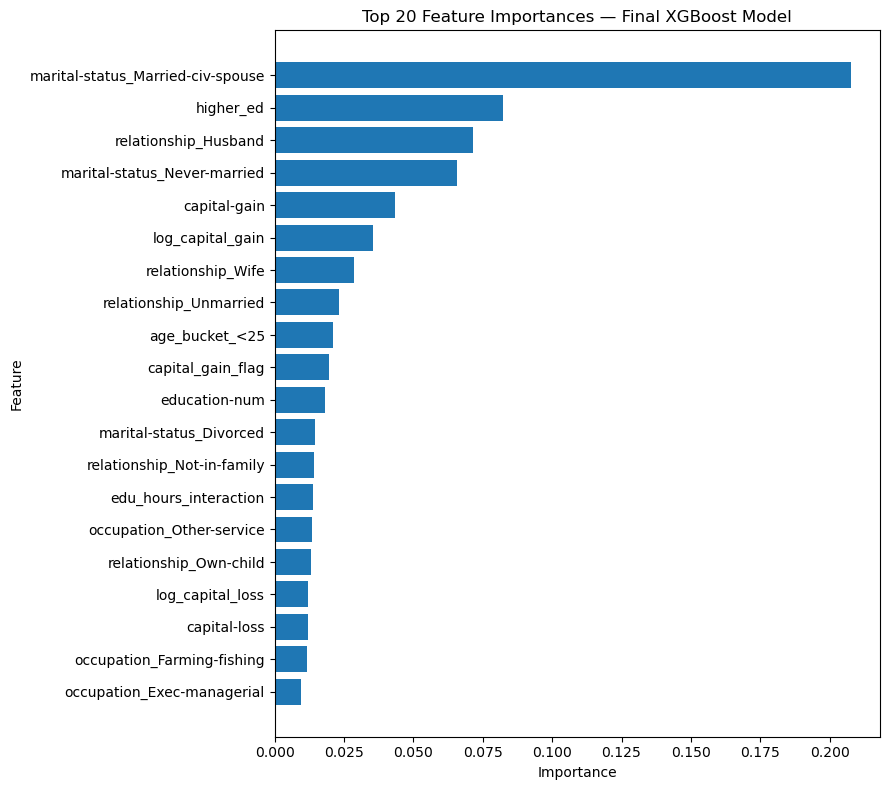

In [22]:
# ============================================================
# TOP FEATURE IMPORTANCE VISUALIZATION
# ============================================================

TOP_N = 20

top_features = (
    feature_importance_df
    .head(TOP_N)
    .sort_values(
        "importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N} Feature Importances — Final XGBoost Model"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

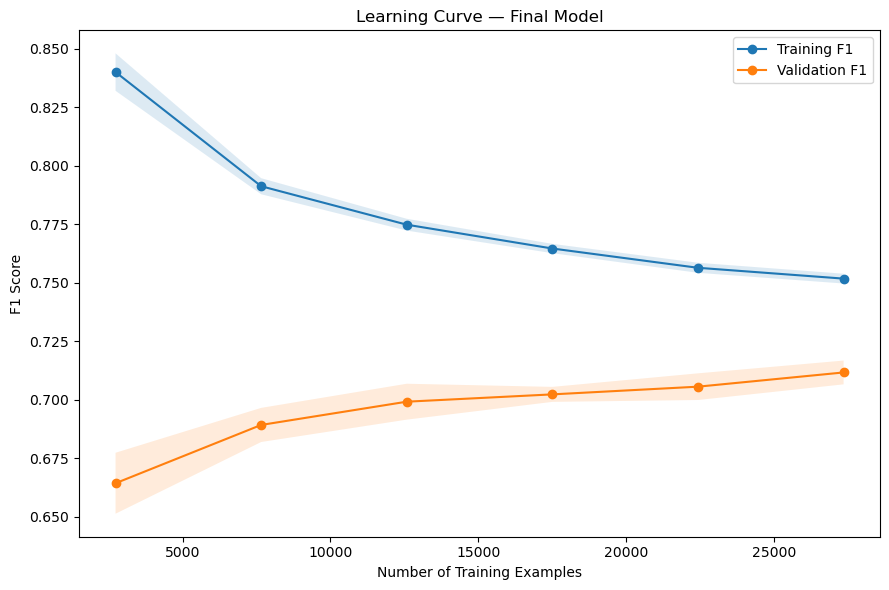

Final training F1: 0.7517
Final validation F1: 0.7116
Train-validation gap: 0.0401


In [23]:
# ============================================================
# FINAL LEARNING CURVE
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_sizes, train_scores, validation_scores = (
    learning_curve(
        final_pipeline,
        X_train,
        y_train,
        train_sizes=np.linspace(
            0.1,
            1.0,
            6
        ),
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    "o-",
    label="Training F1"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.plot(
    train_sizes,
    validation_mean,
    "o-",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Examples")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Final Model")

plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "learning_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

final_gap = (
    train_mean[-1] -
    validation_mean[-1]
)

print(
    f"Final training F1: "
    f"{train_mean[-1]:.4f}"
)

print(
    f"Final validation F1: "
    f"{validation_mean[-1]:.4f}"
)

print(
    f"Train-validation gap: "
    f"{final_gap:.4f}"
)

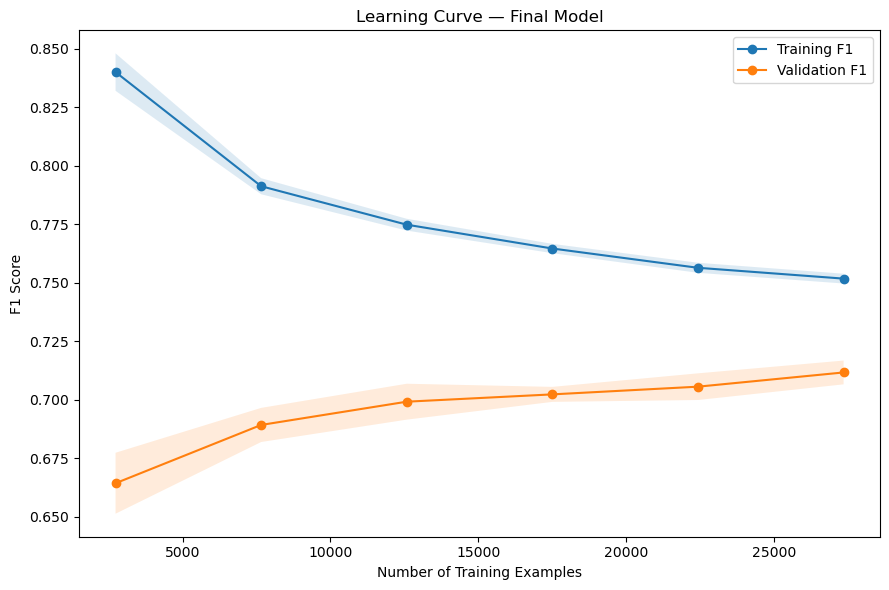

Final training F1: 0.7517
Final validation F1: 0.7116
Train-validation gap: 0.0401


In [24]:
# ============================================================
# FINAL LEARNING CURVE
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_sizes, train_scores, validation_scores = (
    learning_curve(
        final_pipeline,
        X_train,
        y_train,
        train_sizes=np.linspace(
            0.1,
            1.0,
            6
        ),
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    "o-",
    label="Training F1"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.plot(
    train_sizes,
    validation_mean,
    "o-",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Examples")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Final Model")

plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "learning_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

final_gap = (
    train_mean[-1] -
    validation_mean[-1]
)

print(
    f"Final training F1: "
    f"{train_mean[-1]:.4f}"
)

print(
    f"Final validation F1: "
    f"{validation_mean[-1]:.4f}"
)

print(
    f"Train-validation gap: "
    f"{final_gap:.4f}"
)

In [25]:
# ============================================================
# PRODUCTION INFERENCE FUNCTION
# ============================================================

def predict_income(
    model,
    input_data,
    threshold=FINAL_THRESHOLD
):
    """
    Production inference function.

    Parameters
    ----------
    model:
        Saved sklearn pipeline.

    input_data:
        Raw Adult Census DataFrame.

    threshold:
        Probability threshold selected on development data.

    Returns
    -------
    DataFrame containing:
        probability
        prediction
        predicted_class
    """

    if not isinstance(
        input_data,
        pd.DataFrame
    ):
        raise TypeError(
            "input_data must be a pandas DataFrame."
        )

    required_columns = set(
        X.columns
    )

    missing_columns = (
        required_columns -
        set(input_data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    probabilities = (
        model
        .predict_proba(input_data)[:, 1]
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    result = input_data.copy()

    result["probability_>50K"] = probabilities

    result["prediction"] = predictions

    result["predicted_income"] = np.where(
        predictions == 1,
        ">50K",
        "<=50K"
    )

    return result


# ------------------------------------------------------------
# 10 unseen examples
# ------------------------------------------------------------

unseen_examples = X_test.iloc[:10].copy()

inference_results = predict_income(
    final_pipeline,
    unseen_examples,
    FINAL_THRESHOLD
)

print("=" * 70)
print("PRODUCTION INFERENCE TEST")
print("=" * 70)

print(
    inference_results[
        [
            "probability_>50K",
            "prediction",
            "predicted_income"
        ]
    ].round(4)
)

PRODUCTION INFERENCE TEST
       probability_>50K  prediction predicted_income
40421            0.0044           0            <=50K
47738            0.0726           0            <=50K
518              0.0025           0            <=50K
8564             0.0337           0            <=50K
31355            0.5550           1             >50K
1344             0.0092           0            <=50K
6492             0.8574           1             >50K
8815             0.0213           0            <=50K
11275            0.2509           0            <=50K
28595            0.2129           0            <=50K


In [26]:
# ============================================================
# SAVE PRODUCTION ARTIFACT
# ============================================================

FINAL_ARTIFACT_PATH = (
    OUTPUT_DIR /
    "final_model.joblib"
)

joblib.dump(
    final_pipeline,
    FINAL_ARTIFACT_PATH
)

print(
    "Production artifact saved:"
)

print(
    FINAL_ARTIFACT_PATH.resolve()
)

# Verify it exists
assert FINAL_ARTIFACT_PATH.exists()

print(
    "\n✓ Artifact save verification PASSED"
)

Production artifact saved:
E:\Web3 Geeks\T5\day5_final\final_model.joblib

✓ Artifact save verification PASSED


In [27]:
# ============================================================
# MODEL METADATA
# ============================================================

metadata = {
    "project": "UCI Adult Census Income Classification",

    "target": "income >50K",

    "positive_class": 1,

    "negative_class": 0,

    "random_state": RANDOM_STATE,

    "split": {
        "train": 0.70,
        "dev": 0.10,
        "test": 0.20
    },

    "selected_model": "XGBoost",

    "classification_threshold": FINAL_THRESHOLD,

    "metrics": {
        key: float(value)
        for key, value in final_metrics.items()
    },

    "feature_count_after_preprocessing": int(
        len(feature_names)
    ),

    "artifact": str(
        FINAL_ARTIFACT_PATH
    ),

    "python_version": platform.python_version(),

    "numpy_version": np.__version__,

    "pandas_version": pd.__version__,

    "scipy_version": scipy.__version__,

    "scikit_learn_version": sklearn.__version__,

    "xgboost_version": xgb.__version__,

    "joblib_version": joblib.__version__
}

with open(
    OUTPUT_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    json.dumps(
        metadata,
        indent=4
    )
)

{
    "project": "UCI Adult Census Income Classification",
    "target": "income >50K",
    "positive_class": 1,
    "negative_class": 0,
    "random_state": 42,
    "split": {
        "train": 0.7,
        "dev": 0.1,
        "test": 0.2
    },
    "selected_model": "XGBoost",
    "classification_threshold": 0.35000000000000003,
    "metrics": {
        "accuracy": 0.8623195823523391,
        "precision": 0.685607476635514,
        "recall": 0.7844311377245509,
        "f1": 0.7316975862756833,
        "roc_auc": 0.9311013476823964,
        "pr_auc": 0.8356650196700061,
        "brier_score": 0.08627470296493787,
        "threshold": 0.35000000000000003
    },
    "feature_count_after_preprocessing": 119,
    "artifact": "day5_final\\final_model.joblib",
    "python_version": "3.13.9",
    "numpy_version": "2.3.5",
    "pandas_version": "2.3.3",
    "scipy_version": "1.16.3",
    "scikit_learn_version": "1.7.2",
    "xgboost_version": "3.4.1",
    "joblib_version": "1.5.2"
}


In [28]:
# ============================================================
# REQUIREMENTS
# ============================================================

requirements = f"""numpy=={np.__version__}
pandas=={pd.__version__}
scipy=={scipy.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgb.__version__}
joblib=={joblib.__version__}
matplotlib=={plt.matplotlib.__version__}
"""

with open(
    OUTPUT_DIR / "requirements.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(requirements)

print(requirements)

numpy==2.3.5
pandas==2.3.3
scipy==1.16.3
scikit-learn==1.7.2
xgboost==3.4.1
joblib==1.5.2
matplotlib==3.10.6



In [29]:
# ============================================================
# CREATE PRODUCTION INFERENCE SCRIPT
# ============================================================

inference_script = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


MODEL_PATH = Path("final_model.joblib")

# IMPORTANT:
# This threshold was selected using the development set,
# not the final test set.
FINAL_THRESHOLD = __THRESHOLD__


def engineer_features(X):
    X = X.copy()

    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=[
            "<25",
            "25-34",
            "35-44",
            "45-54",
            "55-64",
            "65+"
        ],
        right=False
    ).astype(object)

    X["hours_bin"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 35, 45, 200],
        labels=[
            "part-time(<35)",
            "full-time(35-45)",
            "overtime(>45)"
        ],
        right=False
    ).astype(object)

    X["capital_gain_flag"] = (
        X["capital-gain"] > 0
    ).astype(int)

    X["log_capital_gain"] = np.log1p(
        X["capital-gain"]
    )

    X["capital_loss_flag"] = (
        X["capital-loss"] > 0
    ).astype(int)

    X["log_capital_loss"] = np.log1p(
        X["capital-loss"]
    )

    X["higher_ed"] = (
        X["education-num"] >= 13
    ).astype(int)

    X["edu_hours_interaction"] = (
        X["education-num"] *
        X["hours-per-week"]
    )

    return X


def predict(model, data):
    probabilities = model.predict_proba(data)[:, 1]

    predictions = (
        probabilities >= FINAL_THRESHOLD
    ).astype(int)

    result = data.copy()

    result["probability_>50K"] = probabilities

    result["prediction"] = predictions

    result["predicted_income"] = np.where(
        predictions == 1,
        ">50K",
        "<=50K"
    )

    return result


if __name__ == "__main__":

    model = joblib.load(MODEL_PATH)

    print("Model loaded successfully.")

    # Example raw input.
    example = pd.DataFrame([{
        "age": 39,
        "workclass": "State-gov",
        "fnlwgt": 77516,
        "education": "Bachelors",
        "education-num": 13,
        "marital-status": "Never-married",
        "occupation": "Adm-clerical",
        "relationship": "Not-in-family",
        "race": "White",
        "sex": "Male",
        "capital-gain": 2174,
        "capital-loss": 0,
        "hours-per-week": 40,
        "native-country": "United-States"
    }])

    result = predict(
        model,
        example
    )

    print(result[
        [
            "probability_>50K",
            "prediction",
            "predicted_income"
        ]
    ])
'''.replace(
    "__THRESHOLD__",
    str(FINAL_THRESHOLD)
)

with open(
    OUTPUT_DIR / "inference_example.py",
    "w",
    encoding="utf-8"
) as file:

    file.write(inference_script)

print(
    "Created:",
    OUTPUT_DIR / "inference_example.py"
)

Created: day5_final\inference_example.py
